In [1]:
import torch
import torch.nn as nn


In [2]:
from torchvision.datasets import CIFAR10

In [3]:
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torch import optim

# For reproducability
torch.manual_seed(0)

In [8]:
class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.block1 = nn.Sequential(
        nn.Conv2d(3, 32, 3, 1),      # <- changed from 1 to 3
        nn.BatchNorm2d(32),
        nn.ReLU(inplace=True),
        nn.Conv2d(32, 64, 3, 1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
        nn.Dropout(0.25),
    )
    self.block2 = nn.Sequential(
        nn.Flatten(),
        nn.Linear(12544, 128),        # <- changed from 9216 to 12544
        nn.BatchNorm1d(128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(128, 10),
        nn.BatchNorm1d(10)
    )

  def forward(self, x):
    x = self.block1(x)
    return self.block2(x)



In [ ]:
from torchvision import transforms
# you can change the values of the mean & std given the results you get from your dataset
transform = transforms.Normalize(mean = (0.1307,),
                                 std = (0.3081,))

In [5]:
trainset = CIFAR10('.', train=True, download=True,
                      transform=ToTensor())
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

100%|██████████| 170M/170M [1:04:22<00:00, 44.1kB/s]


In [6]:
from torch.utils.data import random_split

# We divise our training datset into train / validation datasets to detect any potential overfitting
train_size = int(0.9 * len(trainset))  # 45,000 images
val_size = len(trainset) - train_size   # 5,000 images
trainset, valset = random_split(trainset, [train_size, val_size])

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
valloader = DataLoader(valset, batch_size=64, shuffle=False)


In [9]:
num_epochs = 40
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = Net().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    running_loss = 0.0
    num_correct = 0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, idx = outputs.max(dim=1)
        num_correct += (idx == labels).sum().item()

    train_loss = running_loss / len(trainloader)
    train_acc = num_correct / len(trainset)

    # ---- Validation ----
    model.eval()
    val_running_loss = 0.0
    val_num_correct = 0
    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)

            val_running_loss += loss.item()
            _, idx = outputs.max(dim=1)
            val_num_correct += (idx == labels).sum().item()

    val_loss = val_running_loss / len(valloader)
    val_acc = val_num_correct / len(valset)

    print(f'Epoch {epoch+1}/{num_epochs} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')



Epoch 1/40 | Train Loss: 1.3996 Acc: 0.5271 | Val Loss: 1.2274 Acc: 0.5898
Epoch 2/40 | Train Loss: 1.1222 Acc: 0.6279 | Val Loss: 1.0387 Acc: 0.6574
Epoch 3/40 | Train Loss: 1.0086 Acc: 0.6619 | Val Loss: 1.0545 Acc: 0.6462
Epoch 4/40 | Train Loss: 0.9266 Acc: 0.6907 | Val Loss: 0.9656 Acc: 0.6700
Epoch 5/40 | Train Loss: 0.8489 Acc: 0.7161 | Val Loss: 0.8715 Acc: 0.7190
Epoch 6/40 | Train Loss: 0.7897 Acc: 0.7340 | Val Loss: 0.8527 Acc: 0.7130
Epoch 7/40 | Train Loss: 0.7352 Acc: 0.7528 | Val Loss: 0.9480 Acc: 0.6800
Epoch 8/40 | Train Loss: 0.6873 Acc: 0.7699 | Val Loss: 0.8632 Acc: 0.7092
Epoch 9/40 | Train Loss: 0.6397 Acc: 0.7842 | Val Loss: 0.9238 Acc: 0.6898
Epoch 10/40 | Train Loss: 0.5988 Acc: 0.7990 | Val Loss: 1.0018 Acc: 0.6650
Epoch 11/40 | Train Loss: 0.5695 Acc: 0.8092 | Val Loss: 0.9117 Acc: 0.6926
Epoch 12/40 | Train Loss: 0.5347 Acc: 0.8192 | Val Loss: 0.8437 Acc: 0.7230
Epoch 13/40 | Train Loss: 0.5035 Acc: 0.8299 | Val Loss: 0.8141 Acc: 0.7300
Epoch 14/40 | Train L

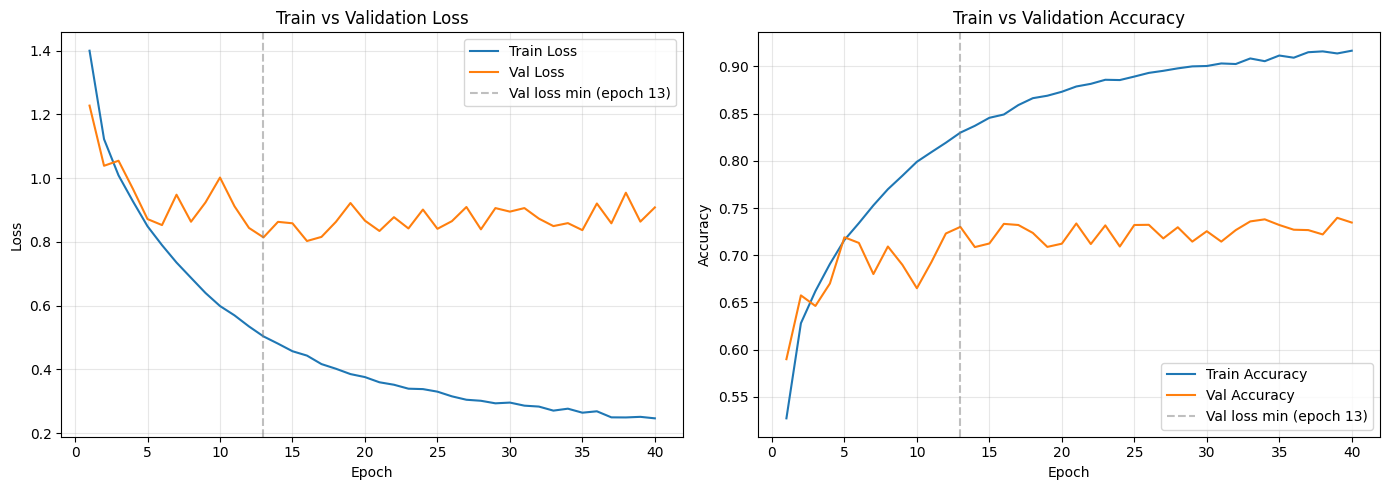

In [14]:
# plot the train / val acc
import matplotlib.pyplot as plt

epochs = list(range(1, 41))

train_loss = [1.3996,1.1222,1.0086,0.9266,0.8489,0.7897,0.7352,0.6873,0.6397,0.5988,
              0.5695,0.5347,0.5035,0.4808,0.4570,0.4433,0.4167,0.4020,0.3853,0.3759,
              0.3596,0.3519,0.3395,0.3382,0.3302,0.3155,0.3048,0.3016,0.2936,0.2959,
              0.2863,0.2834,0.2707,0.2768,0.2642,0.2686,0.2496,0.2493,0.2512,0.2465]

val_loss = [1.2274,1.0387,1.0545,0.9656,0.8715,0.8527,0.9480,0.8632,0.9238,1.0018,
            0.9117,0.8437,0.8141,0.8628,0.8583,0.8027,0.8156,0.8630,0.9219,0.8665,
            0.8342,0.8775,0.8421,0.9014,0.8410,0.8650,0.9094,0.8393,0.9060,0.8949,
            0.9060,0.8729,0.8495,0.8588,0.8368,0.9204,0.8582,0.9542,0.8635,0.9081]

train_acc = [0.5271,0.6279,0.6619,0.6907,0.7161,0.7340,0.7528,0.7699,0.7842,0.7990,
             0.8092,0.8192,0.8299,0.8371,0.8456,0.8491,0.8591,0.8664,0.8690,0.8732,
             0.8788,0.8816,0.8859,0.8856,0.8893,0.8932,0.8954,0.8980,0.9001,0.9005,
             0.9032,0.9026,0.9085,0.9056,0.9116,0.9093,0.9151,0.9160,0.9138,0.9167]

val_acc = [0.5898,0.6574,0.6462,0.6700,0.7190,0.7130,0.6800,0.7092,0.6898,0.6650,
           0.6926,0.7230,0.7300,0.7086,0.7124,0.7332,0.7320,0.7236,0.7088,0.7122,
           0.7336,0.7118,0.7316,0.7092,0.7320,0.7322,0.7178,0.7296,0.7144,0.7254,
           0.7144,0.7266,0.7358,0.7380,0.7320,0.7270,0.7266,0.7220,0.7396,0.7346]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(epochs, train_loss, label='Train Loss')
axes[0].plot(epochs, val_loss, label='Val Loss')
axes[0].axvline(x=13, color='gray', linestyle='--', alpha=0.5, label='Val loss min (epoch 13)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Train vs Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy plot
axes[1].plot(epochs, train_acc, label='Train Accuracy')
axes[1].plot(epochs, val_acc, label='Val Accuracy')
axes[1].axvline(x=13, color='gray', linestyle='--', alpha=0.5, label='Val loss min (epoch 13)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Train vs Validation Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
testset = CIFAR10('.', train=False, download=True, transform=ToTensor())
testloader = DataLoader(testset, batch_size=64, shuffle=False)

In [12]:
# testing the model
model.eval()
test_running_loss = 0.0
test_num_correct = 0

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)

        test_running_loss += loss.item()
        _, idx = outputs.max(dim=1)
        test_num_correct += (idx == labels).sum().item()

test_loss = test_running_loss / len(testloader)
test_acc = test_num_correct / len(testset)

print(f'Test Loss: {test_loss:.4f}  Test Accuracy: {test_acc:.4f}')


Test Loss: 0.9000  Test Accuracy: 0.7310
